## Step 1: Import & Load Data

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx", engine='openpyxl')

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Step 2: Data Cleaning

In [4]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled orders (Invoice starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/Zero quantity
df = df[df['Quantity'] > 0]

df.shape

(397924, 8)

## Step 3: Feature Engineering

In [5]:
# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

## Step 4: RFM Analysis

In [6]:
# Reference date (latest date in dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


## Step 5: RFM Scoring

In [7]:
# Create quartiles
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


## Step 6: Define Churn

In [8]:
# Define churn: customers who haven't purchased in last 90 days
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

rfm['Churn'].value_counts()

Churn
0    2890
1    1449
Name: count, dtype: int64

## Step 7: EDA Visualization

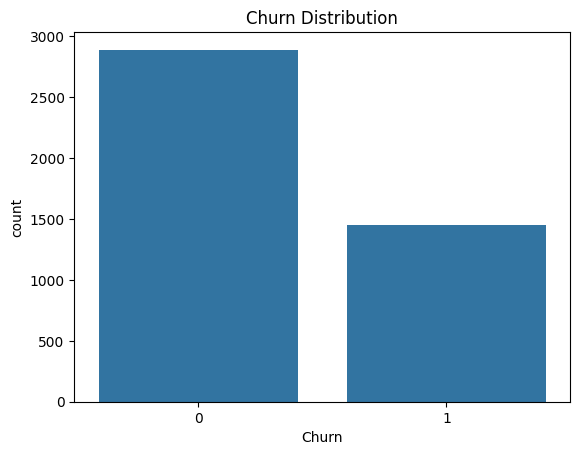

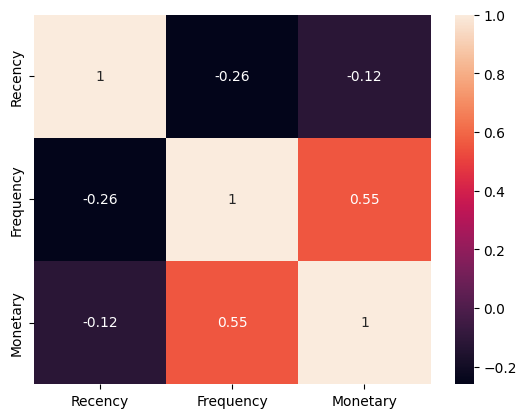

In [9]:
sns.countplot(x='Churn', data=rfm)
plt.title("Churn Distribution")
plt.show()

sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True)
plt.show()

## Step 8: Prepare Data for ML

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 9: Logistic Regression Model

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Step 10: Evaluation

In [12]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9942396313364056
ROC AUC: 0.9916387959866221
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       569
           1       1.00      0.98      0.99       299

    accuracy                           0.99       868
   macro avg       1.00      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868

[[569   0]
 [  5 294]]


## Step 11: Feature Importance

In [13]:
importance = pd.DataFrame({
    'Feature': ['Recency','Frequency','Monetary'],
    'Coefficient': model.coef_[0]
})

print(importance)

     Feature  Coefficient
0    Recency    11.443000
1  Frequency     0.223281
2   Monetary    -0.535629


## Step 12: Business Insights

In [14]:
# High-risk customers
at_risk = rfm[rfm['Churn'] == 1]

# Revenue at risk
revenue_risk = at_risk['Monetary'].sum()

print("Revenue at Risk:", revenue_risk)
print("Total At Risk Customers:", len(at_risk))

Revenue at Risk: 1035270.411
Total At Risk Customers: 1449


## Step 13: Export for Dashboard

In [15]:
rfm.to_csv("rfm_churn_output.csv")

## Step 14: Add SMOTE (Handle Imbalance Properly)

In [18]:
pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_sm))

Before SMOTE: Counter({0: 2321, 1: 1150})
After SMOTE: Counter({1: 2321, 0: 2321})


In [20]:
# Train model on SMOTE data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_sm, y_train_sm)

LogisticRegression()

## Step 15: Build Streamlit App

In [24]:
import pickle

# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [27]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))